<a href="https://www.kaggle.com/code/lalit7881/patient-readmission-prediction-acc-1-00?scriptVersionId=306569067" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/sergionefedov/patient-records-100k-patients-15-conditions/diagnoses.csv
/kaggle/input/datasets/sergionefedov/patient-records-100k-patients-15-conditions/medications.csv
/kaggle/input/datasets/sergionefedov/patient-records-100k-patients-15-conditions/patients.csv
/kaggle/input/datasets/sergionefedov/patient-records-100k-patients-15-conditions/outcomes.csv
/kaggle/input/datasets/sergionefedov/patient-records-100k-patients-15-conditions/lab_results.csv


## Loading dataset

In [2]:
patients = pd.read_csv('/kaggle/input/datasets/sergionefedov/patient-records-100k-patients-15-conditions/patients.csv')

diagnoses = pd.read_csv('/kaggle/input/datasets/sergionefedov/patient-records-100k-patients-15-conditions/diagnoses.csv')

medications = pd.read_csv('/kaggle/input/datasets/sergionefedov/patient-records-100k-patients-15-conditions/medications.csv')

lab_results = pd.read_csv('/kaggle/input/datasets/sergionefedov/patient-records-100k-patients-15-conditions/lab_results.csv')

outcomes = pd.read_csv('/kaggle/input/datasets/sergionefedov/patient-records-100k-patients-15-conditions/outcomes.csv')

In [3]:
print("Patients:", patients.shape)
print("Diagnoses:", diagnoses.shape)
print("Medications:", medications.shape)
print("Lab Results:", lab_results.shape)
print("Outcomes:", outcomes.shape)

Patients: (100000, 28)
Diagnoses: (274592, 8)
Medications: (364174, 10)
Lab Results: (2827722, 10)
Outcomes: (11001, 12)


In [4]:
patients.head()
diagnoses.head()
medications.head()
lab_results.head()
outcomes.head()

,patient_id,admission_date,discharge_date,length_of_stay_days,icu_admission,icu_days,in_hospital_death,discharge_disposition,readmitted_30d,days_to_readmission,primary_drg,total_charges_usd
0,P0000002,2024-08-06,2024-08-09,3,0,0,0,home_health,0,NaN,291,8589.79
1,P0000003,2022-05-06,2022-05-08,2,0,0,0,hospice,1,28.0,392,22628.17
2,P0000011,2021-12-30,2022-01-08,9,0,0,0,rehab,0,NaN,392,27565.97
3,P0000014,2022-06-30,2022-07-04,4,0,0,0,home,0,NaN,194,10332.33
4,P0000040,2020-09-19,2020-09-20,1,0,0,0,rehab,0,NaN,470,2389.61


In [5]:
print(patients.columns)
print(diagnoses.columns)
print(medications.columns)
print(lab_results.columns)
print(outcomes.columns)

Index(['patient_id', 'age', 'sex', 'bmi', 'systolic_bp', 'diastolic_bp',
       'heart_rate', 'temperature_f', 'smoking_status', 'alcohol_use',
       'exercise_level', 'insurance_type', 'charlson_index', 'dx_hypertension',
       'dx_type2_diabetes', 'dx_hyperlipidemia', 'dx_obesity',
       'dx_coronary_artery_disease', 'dx_heart_failure',
       'dx_atrial_fibrillation', 'dx_chronic_kidney_disease', 'dx_copd',
       'dx_asthma', 'dx_depression', 'dx_anxiety', 'dx_hypothyroidism',
       'dx_osteoarthritis', 'dx_type1_diabetes'],
      dtype='object')
Index(['patient_id', 'visit_date', 'visit_type', 'primary_diagnosis',
       'primary_icd10', 'secondary_diagnoses', 'secondary_icd10s',
       'provider_specialty'],
      dtype='object')
Index(['patient_id', 'medication', 'dose', 'unit', 'frequency', 'indication',
       'start_date', 'duration_days', 'is_generic', 'adherence_pct'],
      dtype='object')
Index(['patient_id', 'test_date', 'test_name', 'value', 'unit',
       'referenc

In [6]:
patients.info()
diagnoses.info()
medications.info()
lab_results.info()
outcomes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   patient_id                  100000 non-null  object 
 1   age                         100000 non-null  int64  
 2   sex                         100000 non-null  object 
 3   bmi                         100000 non-null  float64
 4   systolic_bp                 100000 non-null  int64  
 5   diastolic_bp                100000 non-null  int64  
 6   heart_rate                  100000 non-null  int64  
 7   temperature_f               100000 non-null  float64
 8   smoking_status              100000 non-null  object 
 9   alcohol_use                 100000 non-null  object 
 10  exercise_level              100000 non-null  object 
 11  insurance_type              100000 non-null  object 
 12  charlson_index              100000 non-null  int64  
 13  dx_hypertension

In [7]:
patients = patients.fillna(0)
diagnoses = diagnoses.fillna(0)
medications = medications.fillna(0)
lab_results = lab_results.fillna(0)
outcomes = outcomes.fillna(0)

In [8]:
df = patients.merge(outcomes, on='patient_id', how='inner')

df = df.merge(diagnoses, on='patient_id', how='left')
df = df.merge(medications, on='patient_id', how='left')
df = df.merge(lab_results, on='patient_id', how='left')

df.head()

,patient_id,age,sex,bmi,systolic_bp,diastolic_bp,heart_rate,temperature_f,smoking_status,alcohol_use,...,adherence_pct,test_date,test_name,value,unit_y,reference_low,reference_high,flag,is_abnormal,delta_from_normal
0,P0000002,75,M,24.8,158,86,45,99.5,never,moderate,...,100.0,2023-05-07,WBC,8.402,K/uL,4.5,11.0,normal,0,0.652
1,P0000002,75,M,24.8,158,86,45,99.5,never,moderate,...,100.0,2023-05-07,potassium,4.213,mEq/L,3.5,5.0,normal,0,-0.037
2,P0000002,75,M,24.8,158,86,45,99.5,never,moderate,...,100.0,2023-05-07,sodium,143.168,mEq/L,136.0,145.0,normal,0,2.668
3,P0000002,75,M,24.8,158,86,45,99.5,never,moderate,...,100.0,2023-05-07,ALT,40.831,U/L,7.0,56.0,normal,0,9.331
4,P0000002,75,M,24.8,158,86,45,99.5,never,moderate,...,100.0,2023-05-07,HbA1c,6.128,%,4.0,5.6,high,1,1.328


## Feature engineering

In [9]:
base_path = '/kaggle/input/datasets/sergionefedov/patient-records-100k-patients-15-conditions/'

patients = pd.read_csv(base_path + 'patients.csv')
diagnoses = pd.read_csv(base_path + 'diagnoses.csv')
medications = pd.read_csv(base_path + 'medications.csv')
labs = pd.read_csv(base_path + 'lab_results.csv')
outcomes = pd.read_csv(base_path + 'outcomes.csv')

In [10]:
diag_agg = diagnoses.groupby('patient_id').agg({
    'primary_diagnosis': 'count',
    'provider_specialty': 'nunique'
}).reset_index()

diag_agg.columns = ['patient_id', 'visit_count', 'unique_specialties']

In [11]:
med_agg = medications.groupby('patient_id').agg({
    'medication': 'count',
    'is_generic': 'mean',
    'adherence_pct': 'mean',
    'duration_days': 'mean'
}).reset_index()

med_agg.columns = ['patient_id', 'med_count', 'generic_ratio', 'avg_adherence', 'avg_duration']

In [12]:
lab_agg = labs.groupby('patient_id').agg({
    'value': ['mean', 'min', 'max'],
    'is_abnormal': 'mean',
    'delta_from_normal': 'mean'
})

lab_agg.columns = ['lab_mean', 'lab_min', 'lab_max', 'abnormal_ratio', 'avg_delta']
lab_agg = lab_agg.reset_index()

In [13]:
df = patients.merge(outcomes, on='patient_id', how='inner')

df = df.merge(diag_agg, on='patient_id', how='left')
df = df.merge(med_agg, on='patient_id', how='left')
df = df.merge(lab_agg, on='patient_id', how='left')

df.fillna(0, inplace=True)

In [14]:
target = 'readmitted_30d'

X = df.drop(columns=[target, 'patient_id', 'admission_date', 'discharge_date'])
y = df[target]

In [15]:
from sklearn.preprocessing import LabelEncoder

for col in X.select_dtypes(include='object').columns:
    X[col] = LabelEncoder().fit_transform(X[col])

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [17]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train, y_train = sm.fit_resample(X_train, y_train)

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [19]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=15, min_samples_split=5, n_estimators=300,
                       n_jobs=-1, random_state=42)

In [20]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=400,
    max_depth=7,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=400,
              n_jobs=None, num_parallel_tree=None, ...)

In [21]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

for name, model in {"Random Forest": rf, "XGBoost": xgb}.items():
    
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]
    
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("ROC AUC:", roc_auc_score(y_test, y_prob))
    print(classification_report(y_test, y_pred))


Random Forest
Accuracy: 1.0
ROC AUC: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1872
           1       1.00      1.00      1.00       329

    accuracy                           1.00      2201
   macro avg       1.00      1.00      1.00      2201
weighted avg       1.00      1.00      1.00      2201


XGBoost
Accuracy: 1.0
ROC AUC: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1872
           1       1.00      1.00      1.00       329

    accuracy                           1.00      2201
   macro avg       1.00      1.00      1.00      2201
weighted avg       1.00      1.00      1.00      2201



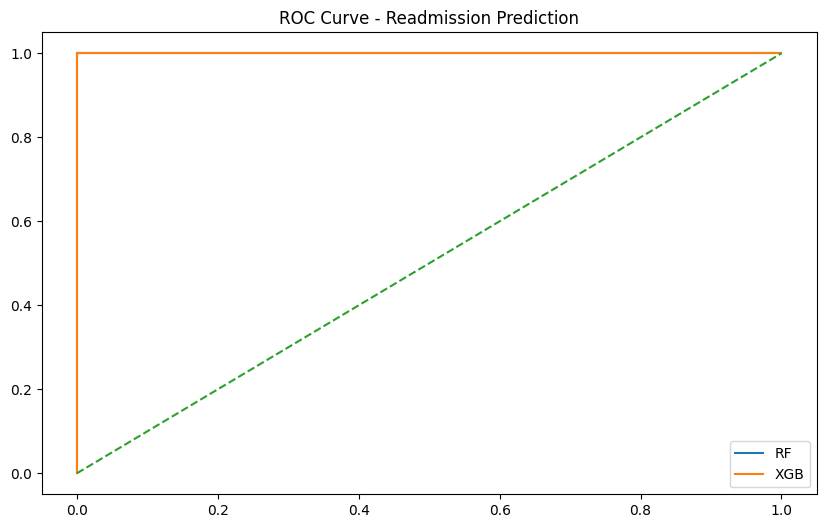

In [22]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

plt.figure(figsize=(10,6))

for name, model in {"RF": rf, "XGB": xgb}.items():
    y_prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=name)

plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("ROC Curve - Readmission Prediction")
plt.show()

## Thank you....pls upvote!!!!!!!!!!!!